**The best neighbourhood is the neighbourhood that offers the most quality of life. To qualify for this metric, the best neighbourhood has to offer the lowest crime, lowest traffic...and the highest number of smart trashes😭😭.**

In [16]:
import matplotlib.pyplot as plt

In [6]:
import pandas as pd

blotter = pd.read_csv("crime_final/blotter.csv", sep=",", on_bad_lines='skip', engine='python')
neighborhoods = pd.read_csv("crime_final/neighborhoods.csv", sep=",", on_bad_lines='skip', engine='python')

crime_counts = {}
for neighborhood in blotter["INCIDENTNEIGHBORHOOD"].unique():
    count = blotter[blotter["INCIDENTNEIGHBORHOOD"] == neighborhood].shape[0]
    crime_counts[neighborhood] = count

results = []
years = 10
for neighborhood, count in crime_counts.items():
    pop_row = neighborhoods[neighborhoods["Neighborhood"] == neighborhood]
    if not pop_row.empty:
        pop = pop_row["Population (2010)"].values[0]
        if pop < 1250:
            continue
        rate = (count / pop) * 1000 / years
        results.append((neighborhood, count, pop, rate))

results.sort(key=lambda x: x[3])
print("Safest neighborhood is: ", results[0][0], "with a rate of ", round(results[0][3], 2), "per 1,000 people\n")
print("Top 5 safest neighborhoods are:")
for neighborhood, count, pop, rate in results[:5]:
    print(neighborhood + ": " + str(round(rate, 2)) + " per 1,000 people")
print("")
for neighborhood, count, pop, rate in results:
    print("Crime rate in ", neighborhood, ": ", str(round(rate, 2)), " per 1,000 people")

Safest neighborhood is:  Central Northside with a rate of  26.89 per 1,000 people

Top 5 safest neighborhoods are:
Central Northside: 26.89 per 1,000 people
Swisshelm Park: 32.55 per 1,000 people
Squirrel Hill North: 35.98 per 1,000 people
Stanton Heights: 40.97 per 1,000 people
Banksville: 43.32 per 1,000 people

Crime rate in  Central Northside :  26.89  per 1,000 people
Crime rate in  Swisshelm Park :  32.55  per 1,000 people
Crime rate in  Squirrel Hill North :  35.98  per 1,000 people
Crime rate in  Stanton Heights :  40.97  per 1,000 people
Crime rate in  Banksville :  43.32  per 1,000 people
Crime rate in  North Oakland :  45.13  per 1,000 people
Crime rate in  Terrace Village :  45.51  per 1,000 people
Crime rate in  Morningside :  46.03  per 1,000 people
Crime rate in  Duquesne Heights :  48.62  per 1,000 people
Crime rate in  Greenfield :  50.15  per 1,000 people
Crime rate in  Squirrel Hill South :  51.68  per 1,000 people
Crime rate in  Lincoln Place :  52.06  per 1,000 peo

The neighbourhood with the best (lowest) crime rate is Central Northside with only 26.89 (crimes per min??crimes in total??) per 1000 people.

In [12]:
df = pd.read_csv("Lowest_traffic/traffic_data.csv")
df.head()

#group the avarage daily traffic by neighborhood avg
traffic_mean = df.groupby("neighborhood")["average_daily_car_traffic"].mean()
#sort by the 10 lowest traffic neighborhoods
lowest_traffic_mean = traffic_mean.sort_values().head(50)
#print them
print(lowest_traffic_mean)

neighborhood
South Side Flats              115.000000
Lincoln Place                 126.000000
Lincoln-Lemington-Belmar      195.000000
Fineview                      419.000000
Allegheny West                477.000000
New Homestead                 666.000000
Overbrook                     777.000000
Summer Hill                   937.000000
Upper Hill                    953.333333
Central Northside            1189.000000
Spring Garden                1226.000000
Hazelwood                    1289.500000
Spring Hill-City View        1293.000000
Elliott                      1342.666667
Beechview                    1418.333333
Windgap                      1531.000000
Highland Park                1564.733333
Beltzhoover                  1577.000000
Lower Lawrenceville          1736.000000
Bluff                        1788.333333
East Allegheny               1924.000000
Carrick                      1969.571429
Morningside                  2049.285714
Perry North                  2123.777778
Man

With this, we can see that South Side Flats has the least amount of cars causing traffic daily, however, looking at the crime dataset again, South Side Flats has one of the highest crime rates. Central Northside makes an appearance again as the 10th lowest neighbourhood with traffic, though.

Last but not least, smart trashes.

In [9]:
trash = pd.read_csv("smart-trash/trash.csv")
trash['neighborhood'].value_counts().head(10)

neighborhood
Shadyside                76
East Liberty             68
Squirrel Hill South      63
Bloomfield               58
North Shore              53
South Side Flats         51
Strip District           42
Carrick                  38
Central Oakland          34
Central Lawrenceville    29
Name: count, dtype: int64

As Shadyside takes 1st place for smart trashes, Central Northside doesn't even make an appearance in the top 10, which means we have to increase the boundaries a little bit.

In [13]:
trash['neighborhood'].value_counts().head(50)

neighborhood
Shadyside                76
East Liberty             68
Squirrel Hill South      63
Bloomfield               58
North Shore              53
South Side Flats         51
Strip District           42
Carrick                  38
Central Oakland          34
Central Lawrenceville    29
Middle Hill              29
Lower Lawrenceville      29
Bluff                    28
Homewood South           28
East Allegheny           26
Mount Washington         25
Brighton Heights         24
Squirrel Hill North      22
Crawford-Roberts         21
Larimer                  20
Hazelwood                18
Marshall-Shadeland       17
Brookline                17
Sheraden                 16
Perry North              15
Troy Hill                15
Allegheny West           15
Upper Lawrenceville      15
North Oakland            14
Greenfield               14
Polish Hill              13
Perry South              12
Elliott                  12
Friendship               12
Highland Park            12
Point B

Central Northside is pretty lacking in its smart trashes but it has a really really good crime rate and pretty decently low amount of cars per day. The winner in terms of pure even distribution would be Highland Park because it is consistently decent across categories (it has more smart trashes than Central Northside). But Central Northside's crime rate is so low (the lowest) that honestly, it having less smart trashes can be overlooked.

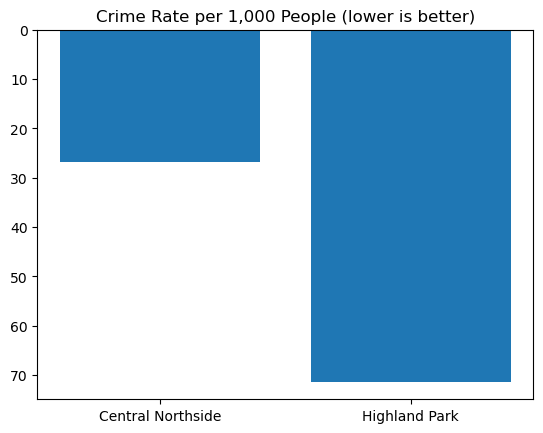

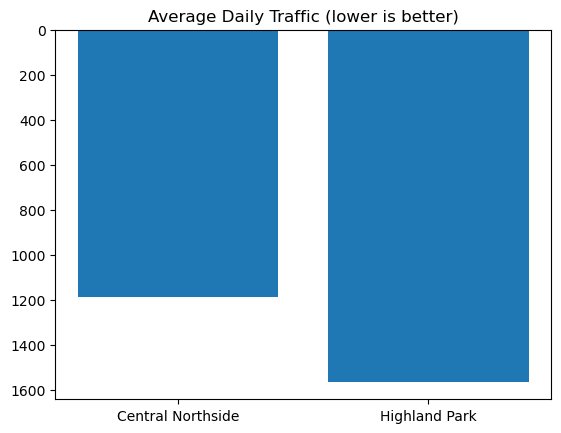

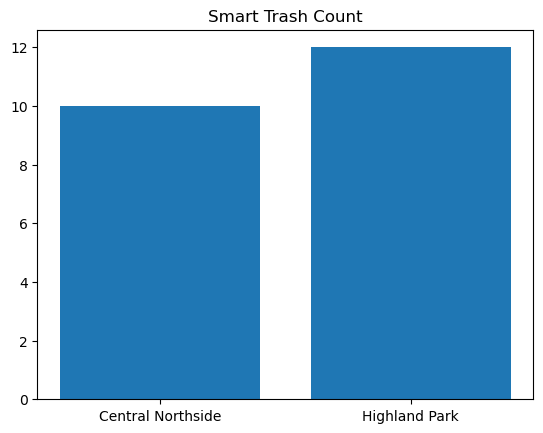

In [19]:
import matplotlib.pyplot as plt

neighborhoods = ["Central Northside", "Highland Park"]
crime_rate = [26.89, 71.34]
traffic = [1189, 1564.733333]
smart_trash = [10, 12]

plt.bar(neighborhoods, crime_rate)
plt.title("Crime Rate per 1,000 People (lower is better)")
plt.gca().invert_yaxis()
plt.show()

plt.bar(neighborhoods, traffic)
plt.title("Average Daily Traffic (lower is better)")
plt.gca().invert_yaxis()
plt.show()

plt.bar(neighborhoods, smart_trash)
plt.title("Smart Trash Count")
plt.show()

To help visualize this **just** a little better, we converted everything to percentages to show a clear difference.

In [20]:
# how much better CN is than HP in each category (as %)
# crime - lower is better, so HP minus CN
crime_advantage = ((crime_rate[1] - crime_rate[0]) / crime_rate[1]) * 100

# traffic - lower is better, so HP minus CN
traffic_advantage = ((traffic[1] - traffic[0]) / traffic[1]) * 100

# smart trash - higher is better, so CN minus HP
trash_advantage = ((smart_trash[0] - smart_trash[1]) / smart_trash[1]) * 100

overall = (crime_advantage + traffic_advantage + trash_advantage) / 3

print("Crime rate: CN is " + str(round(crime_advantage, 1)) + "% better than HP")
print("Traffic: CN is " + str(round(traffic_advantage, 1)) + "% better than HP")
print("Smart trash: CN is " + str(round(trash_advantage, 1)) + "% better than HP")
print()
print("Overall: CN is " + str(round(overall, 1)) + "% better on average")

Crime rate: CN is 62.3% better than HP
Traffic: CN is 24.0% better than HP
Smart trash: CN is -16.7% better than HP

Overall: CN is 23.2% better on average


**Our overall winner is Central Northside!!**